In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
import scipy.stats as st
from math import factorial
import matplotlib.pyplot as plt, seaborn as sns

import warnings
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

In [ ]:
df = pd.read_excel('/content/data analysis.xlsx')

In [ ]:
print (df)

    Sl.no.  Accident_Index Accident Date  Year Day_of_Week  Unnamed: 5  \
0        1         2010000    2021-12-22  2021     Tuesday         2.0   
1        2        20100000    2021-12-23  2021   Wednesday         4.0   
2        3       201000000    2022-01-08  2022      Friday         6.0   
3        4       201000000    2022-09-29  2022   Wednesday         4.0   
4        5     20099700211    2021-11-01  2021      Sunday         1.0   
..     ...             ...           ...   ...         ...         ...   
94      95     20099707103    2021-03-25  2021   Wednesday         4.0   
95      96     20099707203    2021-03-25  2021   Wednesday         4.0   
96      97     20099707511    2021-11-29  2021      Sunday         1.0   
97      98     20099707707    2021-07-23  2021    Thursday         5.0   
98      99     20099707912    2021-12-25  2021      Friday         NaN   

                Junction_Control                      Junction_Detail  \
0       Give way or uncontrolled      

In [ ]:
df.head()

,Sl.no.,Accident_Index,Accident Date,Year,Day_of_Week,Unnamed: 5,Junction_Control,Junction_Detail,Accident_Severity,Latitude,...,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Number_of_Casualties
0,1,2010000,2021-12-22,2021,Tuesday,2.0,Give way or uncontrolled,T or staggered junction,Serious,52.156675,...,2,West Mercia,Frost or ice,Single carriageway,30,07:00:00,Rural,Fog or mist,Car,2
1,2,20100000,2021-12-23,2021,Wednesday,4.0,Data missing or out of range,Not at junction or within 20 metres,Slight,52.035365,...,2,West Mercia,Frost or ice,Single carriageway,60,10:45:00,Rural,Other,Taxi/Private hire car,2
2,3,201000000,2022-01-08,2022,Friday,4.0,Give way or uncontrolled,Roundabout,Serious,51.917709,...,3,Hertfordshire,Wet or damp,Dual carriageway,40,13:08:00,Urban,Fine no high winds,Car,2
3,4,201000000,2022-09-29,2022,Wednesday,4.0,Data missing or out of range,Not at junction or within 20 metres,Serious,52.074002,...,1,West Mercia,Dry,Single carriageway,30,18:15:00,Rural,Fine no high winds,Van / Goods 3.5 tonnes mgw or under,1
4,5,20099700211,2021-11-01,2021,Sunday,1.0,Data missing or out of range,Not at junction or within 20 metres,Slight,55.860055,...,2,Strathclyde,Wet or damp,Single carriageway,30,16:45:00,Urban,Raining + high winds,Car,1


In [ ]:
df.shape

(99, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Sl.no.                      99 non-null     int64         
 1   Accident_Index              99 non-null     int64         
 2   Accident Date               99 non-null     datetime64[ns]
 3   Year                        99 non-null     int64         
 4   Day_of_Week                 99 non-null     object        
 5   Unnamed: 5                  68 non-null     float64       
 6   Junction_Control            99 non-null     object        
 7   Junction_Detail             99 non-null     object        
 8   Accident_Severity           99 non-null     object        
 9   Latitude                    99 non-null     float64       
 10  Longitude                   99 non-null     float64       
 11  Light_Conditions            99 non-null     object        
 

In [ ]:
df.isna().sum() / len(df)

,0
Sl.no.,0.000000
Accident_Index,0.000000
Accident Date,0.000000
Year,0.000000
Day_of_Week,0.000000
Unnamed: 5,0.404040
Junction_Control,0.000000
Junction_Detail,0.000000
Accident_Severity,0.000000
Latitude,0.000000


In [ ]:
df.head(20)

,Sl.no.,Accident_Index,Accident Date,Year,Day_of_Week,Unnamed: 5,Junction_Control,Junction_Detail,Accident_Severity,Latitude,...,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Number_of_Casualties
0,1,2010000,2021-12-22,2021,Tuesday,2.0,Give way or uncontrolled,T or staggered junction,Serious,52.156675,...,2,West Mercia,Frost or ice,Single carriageway,30,07:00:00,Rural,Fog or mist,Car,2
1,2,20100000,2021-12-23,2021,Wednesday,4.0,Data missing or out of range,Not at junction or within 20 metres,Slight,52.035365,...,2,West Mercia,Frost or ice,Single carriageway,60,10:45:00,Rural,Other,Taxi/Private hire car,2
2,3,201000000,2022-01-08,2022,Friday,4.0,Give way or uncontrolled,Roundabout,Serious,51.917709,...,3,Hertfordshire,Wet or damp,Dual carriageway,40,13:08:00,Urban,Fine no high winds,Car,2
3,4,201000000,2022-09-29,2022,Wednesday,4.0,Data missing or out of range,Not at junction or within 20 metres,Serious,52.074002,...,1,West Mercia,Dry,Single carriageway,30,18:15:00,Rural,Fine no high winds,Van / Goods 3.5 tonnes mgw or under,1
4,5,20099700211,2021-11-01,2021,Sunday,1.0,Data missing or out of range,Not at junction or within 20 metres,Slight,55.860055,...,2,Strathclyde,Wet or damp,Single carriageway,30,16:45:00,Urban,Raining + high winds,Car,1
5,6,20099700410,2021-10-04,2021,Sunday,1.0,Data missing or out of range,Not at junction or within 20 metres,Slight,55.855486,...,1,Strathclyde,Dry,Single carriageway,30,21:30:00,Urban,Fine no high winds,Motorcycle over 500cc,1
6,7,20099700412,2021-12-03,2021,Thursday,5.0,Data missing or out of range,Not at junction or within 20 metres,Slight,55.847621,...,2,Strathclyde,Wet or damp,Single carriageway,30,16:10:00,Urban,Fine no high winds,Goods over 3.5t. and under 7.5t,1
7,8,20099700501,2021-01-05,2021,Monday,2.0,Data missing or out of range,Not at junction or within 20 metres,Slight,55.882892,...,2,Strathclyde,Wet or damp,Single carriageway,60,17:15:00,Rural,Fine no high winds,Motorcycle 125cc and under,1
8,9,20099700504,2021-04-01,2021,Wednesday,4.0,Data missing or out of range,Not at junction or within 20 metres,Serious,55.865600,...,1,Strathclyde,Dry,Single carriageway,30,21:10:00,Urban,Fine no high winds,Car,1
9,10,20099700507,2021-07-03,2021,Friday,4.0,Data missing or out of range,Not at junction or within 20 metres,Slight,55.888853,...,1,Strathclyde,Wet or damp,Single carriageway,30,19:55:00,Rural,Fine no high winds,Goods over 3.5t. and under 7.5t,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Sl.no.                      99 non-null     int64         
 1   Accident_Index              99 non-null     int64         
 2   Accident Date               99 non-null     datetime64[ns]
 3   Year                        99 non-null     int64         
 4   Day_of_Week                 99 non-null     object        
 5   Unnamed: 5                  68 non-null     float64       
 6   Junction_Control            99 non-null     object        
 7   Junction_Detail             99 non-null     object        
 8   Accident_Severity           99 non-null     object        
 9   Latitude                    99 non-null     float64       
 10  Longitude                   99 non-null     float64       
 11  Light_Conditions            99 non-null     object        
 

In [ ]:
df.isnull().sum()

,0
Sl.no.,0
Accident_Index,0
Accident Date,0
Year,0
Day_of_Week,0
Unnamed: 5,31
Junction_Control,0
Junction_Detail,0
Accident_Severity,0
Latitude,0


In [ ]:
df.describe

<bound method NDFrame.describe of     Sl.no.  Accident_Index Accident Date  Year Day_of_Week  Unnamed: 5  \
0        1         2010000    2021-12-22  2021     Tuesday         2.0   
1        2        20100000    2021-12-23  2021   Wednesday         4.0   
2        3       201000000    2022-01-08  2022      Friday         4.0   
3        4       201000000    2022-09-29  2022   Wednesday         4.0   
4        5     20099700211    2021-11-01  2021      Sunday         1.0   
..     ...             ...           ...   ...         ...         ...   
94      95     20099707103    2021-03-25  2021   Wednesday         4.0   
95      96     20099707203    2021-03-25  2021   Wednesday         4.0   
96      97     20099707511    2021-11-29  2021      Sunday         1.0   
97      98     20099707707    2021-07-23  2021    Thursday         5.0   
98      99     20099707912    2021-12-25  2021      Friday         NaN   

                Junction_Control                      Junction_Detail  \
0       Give way or uncontrolled              T or staggered junction   
1   Data missing or out of range  Not at junction or within 20 metres   
2       Give way or uncontrolled                           Roundabout   
3   Data missing or out of range  Not at junction or within 20 metres   
4   Data missing or out of range  Not at junction or within 20 metres   
..                           ...                                  ...   
94  Data missing or out of range  Not at junction or within 20 metres   
95  Data missing or out of range  Not at junction or within 20 metres   
96  Data missing or out of range  Not at junction or within 20 metres   
97  Data missing or out of range  Not at junction or within 20 metres   
98  Data missing or out of range  Not at junction or within 20 metres   

   Accident_Severity   Latitude  ...  Number_of_Vehicles   Police_Force  \
0            Serious  52.156675  ...                   2    West Mercia   
1             Slight  52.035365  ...                   2    West Mercia   
2            Serious  51.917709  ...                   3  Hertfordshire   
3            Serious  52.074002  ...                   1    West Mercia   
4             Slight  55.860055  ...                   2    Strathclyde   
..               ...        ...  ...                 ...            ...   
94            Slight  55.845310  ...                   3    Strathclyde   
95            Slight  55.866040  ...                   3    Strathclyde   
96            Slight  55.862781  ...                   1    Strathclyde   
97            Slight  55.843984  ...                   2    Strathclyde   
98           Serious  55.910355  ...                   1    Strathclyde   

   Road_Surface_Conditions           Road_Type  Speed_limit      Time  \
0             Frost or ice  Single carriageway           30  07:00:00   
1             Frost or ice  Single carriageway           60  10:45:00   
2              Wet or damp    Dual carriageway           40  13:08:00   
3                      Dry  Single carriageway           30  18:15:00   
4              Wet or damp  Single carriageway           30  16:45:00   
..                     ...                 ...          ...       ...   
94             Wet or damp    Dual carriageway           40  08:45:00   
95                     Dry  Single carriageway           30  12:20:00   
96                     Dry  Single carriageway           30  13:50:00   
97                     Dry    Dual carriageway           70  18:25:00   
98                    Snow  Single carriageway           30  05:45:00   

   Urban_or_Rural_Area     Weather_Conditions  \
0                Rural            Fog or mist   
1                Rural                  Other   
2                Urban     Fine no high winds   
3                Rural     Fine no high winds   
4                Urban   Raining + high winds   
..                 ...                    ...   
94               Urban     Fine no high winds   
95               Urban     Fin

In [ ]:
df.describe(include='object')

,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Police_Force,Road_Surface_Conditions,Road_Type,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
count,99,99,99,99,99,99,1,99,99,99,99,99,99,99
unique,7,2,3,2,5,3,1,3,4,3,81,2,6,11
top,Thursday,Data missing or out of range,Not at junction or within 20 metres,Slight,Daylight,North Larkshire,Other object on road,Strathclyde,Wet or damp,Single carriageway,16:45:00,Urban,Fine no high winds,Car
freq,21,97,97,82,65,95,1,95,52,78,3,70,66,29


In [ ]:
categorical_column = ['Day_of_Week', 'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Light_Conditions', 'Time']
for column in categorical_column:
  print(column)
  print((df[column].unique()))
  print()

Day_of_Week
['Tuesday' 'Wednesday' 'Friday' 'Sunday' 'Thursday' 'Monday' 'Saturday']

Junction_Control
['Give way or uncontrolled' 'Data missing or out of range']

Junction_Detail
['T or staggered junction' 'Not at junction or within 20 metres'
 'Roundabout']

Accident_Severity
['Serious' 'Slight']

Light_Conditions
['Darkness - no lighting' 'Daylight' 'Darkness - lights lit'
 'Darkness - lights unlit' 'Darkness - lighting unknown']

Time
[datetime.time(7, 0) datetime.time(10, 45) datetime.time(13, 8)
 datetime.time(18, 15) datetime.time(16, 45) datetime.time(21, 30)
 datetime.time(16, 10) datetime.time(17, 15) datetime.time(21, 10)
 datetime.time(19, 55) datetime.time(0, 15) datetime.time(16, 20)
 datetime.time(9, 50) datetime.time(21, 40) datetime.time(19, 50)
 datetime.time(18, 30) datetime.time(23, 10) datetime.time(19, 20)
 datetime.time(15, 0) datetime.time(13, 5) datetime.time(4, 10)
 datetime.time(17, 11) datetime.time(6, 0) datetime.time(23, 40)
 datetime.time(13, 40) datetime

In [ ]:
def data_imputation(data, column_grouping, column_selected):
    group = data[column_grouping].unique()

    for value in group:

        if pd.api.types.is_numeric_dtype(data[column_selected]):
            imputation_value = data.loc[(data[column_grouping]==value) & ~(data[column_selected].isna()), column_selected].median()
        else:

            imputation_value = data.loc[(data[column_grouping]==value) & ~(data[column_selected].isna()), column_selected].mode()[0]

        data.loc[(data[column_grouping]==value) & (data[column_selected].isna()), column_selected] = imputation_value

    return data

<Axes: >

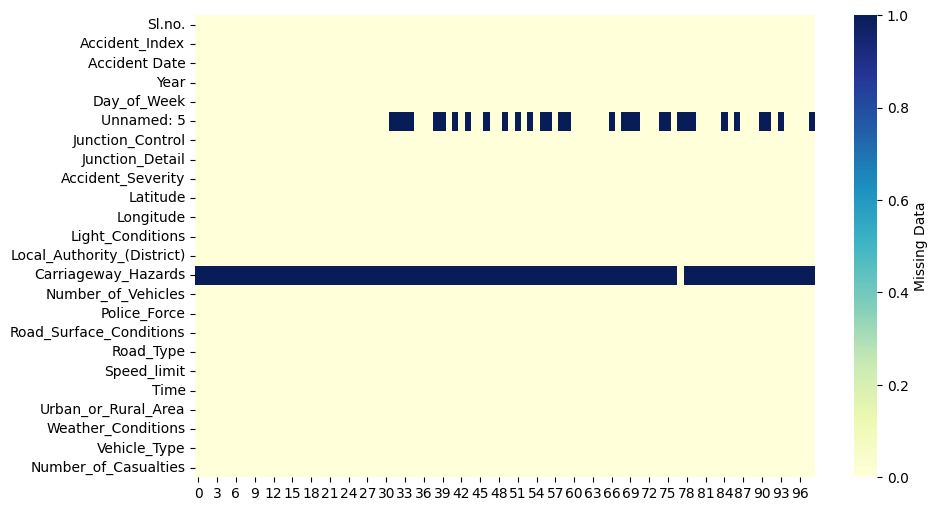

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna().transpose(),
            cmap="YlGnBu",
            cbar_kws={'label': 'Missing Data'})

<Axes: ylabel='Accident Date'>

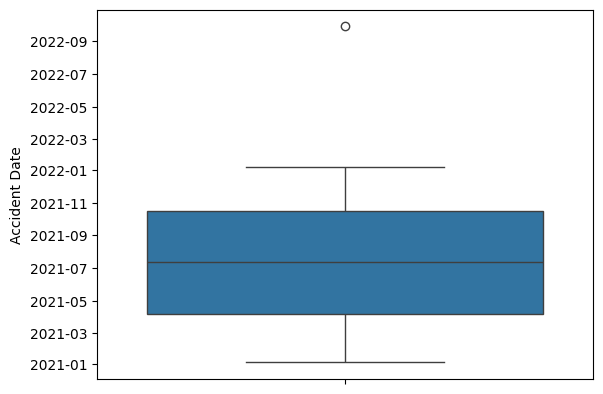

In [ ]:
sns.boxplot(df['Accident Date'])

<Axes: ylabel='Speed_limit'>

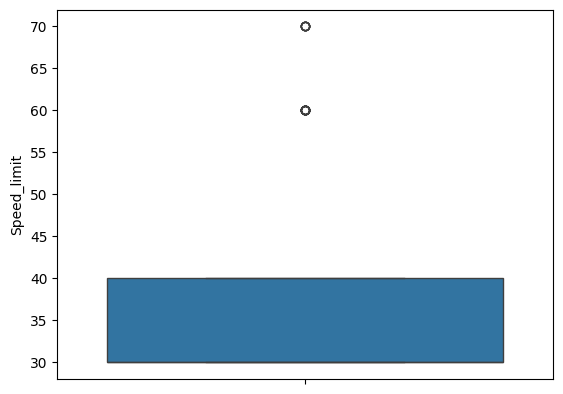

In [ ]:
sns.boxplot(df['Speed_limit'])

In [ ]:
df['Accident Date'].describe()

,Accident Date
count,99
mean,2021-07-12 06:32:43.636363520
min,2021-01-05 00:00:00
25%,2021-04-05 00:00:00
50%,2021-07-13 00:00:00
75%,2021-10-16 12:00:00
max,2022-09-29 00:00:00


In [ ]:
df['Speed_limit'].describe()

,Speed_limit
count,99.000000
mean,38.585859
std,13.997821
min,30.000000
25%,30.000000
50%,30.000000
75%,40.000000
max,70.000000


In [ ]:
condition_Speed_limit = df['Speed_limit']==1
df['Speed_limit'] = df['Speed_limit'].mask(condition_Speed_limit, 30)

In [ ]:
df['Speed_limit'] = abs(df['Speed_limit'])

In [ ]:
sorted(df['Speed_limit'].unique())

[np.int64(30), np.int64(40), np.int64(60), np.int64(70)]

In [ ]:
df['']